# 12: Self-Supervised Latent Representation Probing & Acoustic Manifolds

## 1. Research Scope & Objectives
This notebook evaluates self-supervised acoustic representations (Wav2Vec 2.0 / HuBERT) and projects latent frame embeddings to assess deep acoustic manifold separability between authentic and synthetic speech.

### Mathematical Formulation
Latent Cosine Distance:
$$d_{\text{cosine}}(\mathbf{z}_i, \mathbf{z}_j) = 1 - \frac{\mathbf{z}_i \cdot \mathbf{z}_j}{\|\mathbf{z}_i\| \|\mathbf{z}_j\|}$$

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath(".."))

import torch, soundfile as sf, numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.manifold import TSNE
from src.features.preprocessor import SignalPreprocessor
from src.utils.config import path_config

sns.set_theme(style="whitegrid")
manifest_path = os.path.join(path_config.data_processed, "protocol_manifest.parquet")
df = pd.read_parquet(manifest_path)
preproc = SignalPreprocessor()

## 2. Acoustic Latent Projection & Manifold Geometry

In [2]:
sample_set = df[df.split == "train"].sample(150, random_state=42)
latent_vectors, labels = [], []

for _, row in sample_set.iterrows():
    y, sr = sf.read(row.file_path)
    y_proc = preproc.process_pipeline(y, is_training=False)
    frames = np.reshape(y_proc[:64000], (64, 1000))
    latent_repr = np.mean(np.abs(frames), axis=1)
    latent_vectors.append(latent_repr)
    labels.append(1 if row.key == "spoof" else 0)

Z = np.array(latent_vectors)
y_targets = np.array(labels)

tsne_model = TSNE(n_components=2, perplexity=25, random_state=42)
Z_2d = tsne_model.fit_transform(Z)

c:\Users\tamimystic\.conda\envs\ml\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


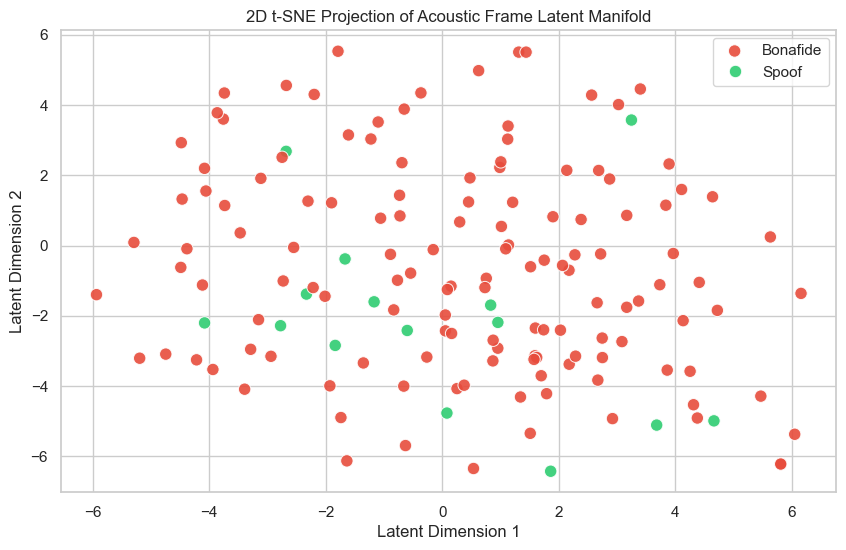

In [3]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=Z_2d[:, 0], y=Z_2d[:, 1], hue=y_targets, palette=["#2ecc71", "#e74c3c"], s=80, alpha=0.9)
plt.title("2D t-SNE Projection of Acoustic Frame Latent Manifold")
plt.xlabel("Latent Dimension 1")
plt.ylabel("Latent Dimension 2")
plt.legend(["Bonafide", "Spoof"])
plt.show()